# Probability Distribution Moments

Antonio Esteves, Jan 2024

## 1. Skewnes of `skewnorm` probability distribution


In [19]:
import numpy             as     np
from   scipy.stats       import skewnorm
from   scipy.stats       import cauchy
import matplotlib.pyplot as     plt
import seaborn           as     sns
from   numpy.random      import RandomState

### 1.1 Calculate the first four moments

In [24]:
a_arr = [-10, -5, -2, -1, 0, 1, 2, 5, 10]

for n, a in enumerate(a_arr):
    mean, var, skew, kurt = skewnorm.stats(a, moments='mvsk')
    print(f'Skewnormal distribution with a={a}:')
    print(f'  Mean:     {mean:.3f}')
    print(f'  Variance: {var:.3f}')
    print(f'  Skewness: {skew:.3f}')
    print(f'  Kurtosis: {kurt:.3f}')

Skewnormal distribution with a=-10:
  Mean:     -0.794
  Variance: 0.370
  Skewness: -0.956
  Kurtosis: 0.823
Skewnormal distribution with a=-5:
  Mean:     -0.782
  Variance: 0.388
  Skewness: -0.851
  Kurtosis: 0.705
Skewnormal distribution with a=-2:
  Mean:     -0.714
  Variance: 0.491
  Skewness: -0.454
  Kurtosis: 0.305
Skewnormal distribution with a=-1:
  Mean:     -0.564
  Variance: 0.682
  Skewness: -0.137
  Kurtosis: 0.062
Skewnormal distribution with a=0:
  Mean:     0.000
  Variance: 1.000
  Skewness: 0.000
  Kurtosis: 0.000
Skewnormal distribution with a=1:
  Mean:     0.564
  Variance: 0.682
  Skewness: 0.137
  Kurtosis: 0.062
Skewnormal distribution with a=2:
  Mean:     0.714
  Variance: 0.491
  Skewness: 0.454
  Kurtosis: 0.305
Skewnormal distribution with a=5:
  Mean:     0.782
  Variance: 0.388
  Skewness: 0.851
  Kurtosis: 0.705
Skewnormal distribution with a=10:
  Mean:     0.794
  Variance: 0.370
  Skewness: 0.956
  Kurtosis: 0.823


### 1.2. Display the probability density function (PDF)

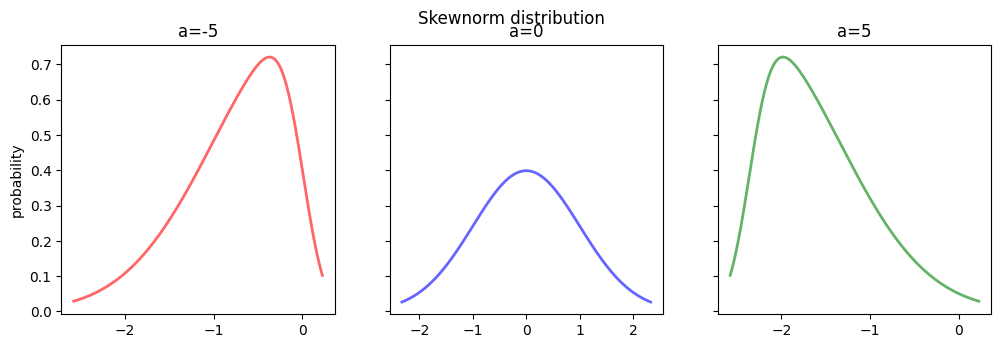

In [17]:
a = [-5, 0, 5]

x0 = np.linspace(skewnorm.ppf(0.01, a[0]), skewnorm.ppf(0.99, a[0]), 1000)
x1 = np.linspace(skewnorm.ppf(0.01, a[1]), skewnorm.ppf(0.99, a[1]), 1000)
x2 = np.linspace(skewnorm.ppf(0.01, a[2]), skewnorm.ppf(0.99, a[2]), 1000)


fig, ax = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12,3.5))

ax[0].plot(x0, skewnorm.pdf(x0, a[0]),'r-', lw=2, alpha=0.6, label='skewnorm pdf')
ax[0].set(title=f'a={a[0]}', ylabel='probability')

ax[1].plot(x1, skewnorm.pdf(x1, a[1]),'b-', lw=2, alpha=0.6, label='skewnorm pdf')
ax[1].set(title=f'a={a[1]}')

ax[2].plot(x0, skewnorm.pdf(x2, a[2]),'g-', lw=2, alpha=0.6, label='skewnorm pdf')
ax[2].set(title=f'a={a[2]}')

fig.suptitle('Skewnorm distribution')
plt.show()


### 1.3. Generate a sample from the distribution

In [59]:
N     = 1000
a_arr = [-5, -2, 0, 2, 5]

rng   = RandomState(seed=42)

for n, a in enumerate(a_arr):

    print( '-----------------------------------')
    print(f'Skewnormal distribution with a={a}:')
    
    mean, var, skew = skewnorm.stats(a, moments='mvs')
    stddev    = np.sqrt(var)

    X         = skewnorm.rvs(a, size=N, random_state=rng)

    X_mean    = X.mean()
    X_stddev  = X.std()
    limit_inf = X_mean - X_stddev
    limit_sup = X_mean + X_stddev

    print(f'  Mean          = {mean:.4f}')
    print(f'  Var           = {var:.4f}')
    print(f'  StdDev        = {stddev:.4f}')
    print(f'  Skewness      = {skew:.4f}')

    print(f'  LimitInf      = {limit_inf:.4f}')
    print(f'  LimitSup      = {limit_sup:.4f}\n')
    print(f'  Sample mean   = {X_mean:.4f}')
    print(f'  Sample stddev = {X_stddev:.4f}\n')

    tail_neg  = (X <  limit_inf).sum()
    tail_pos  = (X >  limit_sup).sum()
    rest      = len(X)-tail_neg-tail_pos

    print(f'  Negative tail probability mass:       {(tail_neg*100)/N}%')
    print(f'  Region within 1 stdDev from the mean: {(rest*100)/N}%')
    print(f'  Positive Tail  probability mass:      {(tail_pos*100)/N}%\n')

    #.................................................

    Z                = (X - X_mean) / X_stddev

    X_skew_tail_neg  = (Z[Z < -1]**3).sum()
    X_skew_tail_pos  = (Z[Z > 1]**3).sum()
    X_skew_not_tails = (Z[abs(Z) <= 1]**3).sum()
    X_skew_total = X_skew_tail_neg + X_skew_not_tails + X_skew_tail_pos

    print(f'  Contribute of negative tail to skewness:   {X_skew_tail_neg:.4f}')
    print(f'  Contribute of non-tail region to skewness: {X_skew_not_tails:.4f}') 
    print(f'  Contribute of positive tail to skewness:   {X_skew_tail_pos:.4f}\n') 

    print(f'  Sample skewness: {X_skew_total/len(X):.5f}')


-----------------------------------
Skewnormal distribution with a=-5:
  Mean          = -0.7824
  Var           = 0.3879
  StdDev        = 0.6228
  Skewness      = -0.8510
  LimitInf      = -1.3873
  LimitSup      = -0.1560

  Sample mean   = -0.7717
  Sample stddev = 0.6156

  Negative tail probability mass:       16.2%
  Region within 1 stdDev from the mean: 68.7%
  Positive Tail  probability mass:      15.1%

  Contribute of negative tail to skewness:   -1220.1429
  Contribute of non-tail region to skewness: 41.1348
  Contribute of positive tail to skewness:   327.3770

  Sample skewness: -0.85163
-----------------------------------
Skewnormal distribution with a=-2:
  Mean          = -0.7136
  Var           = 0.4907
  StdDev        = 0.7005
  Skewness      = -0.4538
  LimitInf      = -1.3902
  LimitSup      = 0.0192

  Sample mean   = -0.6855
  Sample stddev = 0.7047

  Negative tail probability mass:       15.1%
  Region within 1 stdDev from the mean: 70.1%
  Positive Tail  proba

## 2. Kurtosis of the `Cauchy` Distribution

The Cauchy distribution is similar to the normal, but has heavier tails

In [4]:
rng     = RandomState(seed=43)

N       = 1000
X       = cauchy(0, 1).rvs(size=N, random_state=rng)
Z       = (X - X.mean()) / X.std()
k_total = (Z**4).mean()
k_peak  = (Z[abs(Z) <  1]**4).sum() / N
k_tails = (Z[abs(Z) >= 1]**4).sum() / N

print(f'Tails: {k_tails / k_total:.8f}')  # 0.99999669
print(f'Peak : {k_peak  / k_total:.8f}')  # 0.00000331

Tails: 0.99994587
Peak : 0.00005413


### 2.1 Calculate the first four moments of the standard Cauchy distribution

In [5]:
mean, var, skew, kurt = cauchy.stats(moments='mvsk')

print(f'  Mean:     {mean:.3f}')
print(f'  Variance: {var:.3f}')
print(f'  Skewness: {skew:.3f}')
print(f'  Kurtosis: {kurt:.3f}')

  Mean:     nan
  Variance: nan
  Skewness: nan
  Kurtosis: nan


## 2.2 Display the probability density function (PDF)

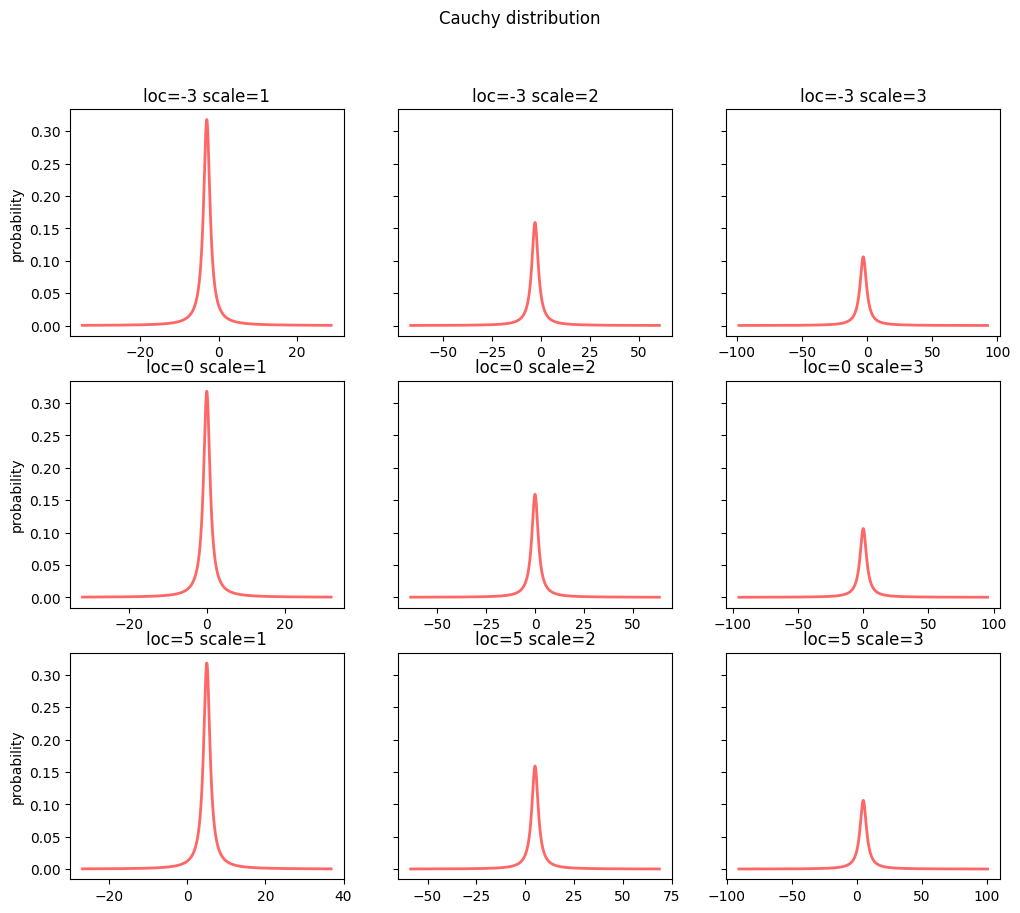

In [11]:
loc_arr   = [-3, 0, 5]
scale_arr = [1, 2, 3]

fig, ax = plt.subplots(nrows=3, ncols=3, sharey=True, figsize=(12,10))

for r, loc in enumerate(loc_arr):
    for c, scale in enumerate(scale_arr):

        x = np.linspace(
            cauchy.ppf(0.01, loc=loc, scale=scale), 
            cauchy.ppf(0.99, loc=loc, scale=scale),
            1000)

        ax[r][c].plot(x, cauchy.pdf(x, loc=loc, scale=scale),'r-', lw=2, alpha=0.6, label='cauchy pdf')
        if c== 0:
            ylabel='probability'
        else:
            ylabel=''
        ax[r][c].set(title=f'loc={loc} scale={scale}', ylabel=ylabel)

fig.suptitle('Cauchy distribution')
plt.show()

### 2.3 Generate a sample from the Cauchy distribution

-----------------------------------
Cauchy distribution with loc=0 scale=1:


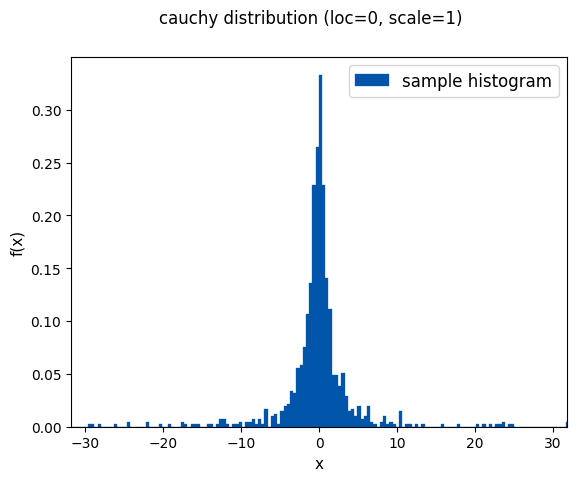

  LimitInf      = -35.4930
  LimitSup      = 37.4985

  Sample mean   = 1.0028
  Sample stddev = 36.4958

  Negative tail probability mass:       0.4%
  Region within 1 stdDev from the mean: 99.2%
  Positive Tail  probability mass:      0.4%

  Contribute of negative tail to kurtosis:   32.0704
  Contribute of non-tail region to kurtosis: 7.2261
  Contribute of positive tail to kurtosis:   907665.7393

  Contribute of tails to kurtosis:   99.999204%
  Contribute of no-tail to kurtosis: 0.000796%
  Sample kurtosis: 907.70504
-----------------------------------
Cauchy distribution with loc=0 scale=2:


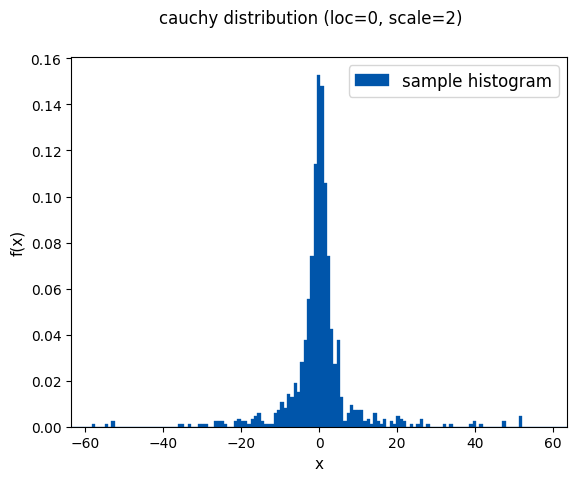

  LimitInf      = -40.2378
  LimitSup      = 45.1649

  Sample mean   = 2.4636
  Sample stddev = 42.7014

  Negative tail probability mass:       1.2%
  Region within 1 stdDev from the mean: 96.7%
  Positive Tail  probability mass:      2.1%

  Contribute of negative tail to kurtosis:   769.9988
  Contribute of non-tail region to kurtosis: 9.6114
  Contribute of positive tail to kurtosis:   425299.0307

  Contribute of tails to kurtosis:   99.997744%
  Contribute of no-tail to kurtosis: 0.002256%
  Sample kurtosis: 426.07864
-----------------------------------
Cauchy distribution with loc=0 scale=5:


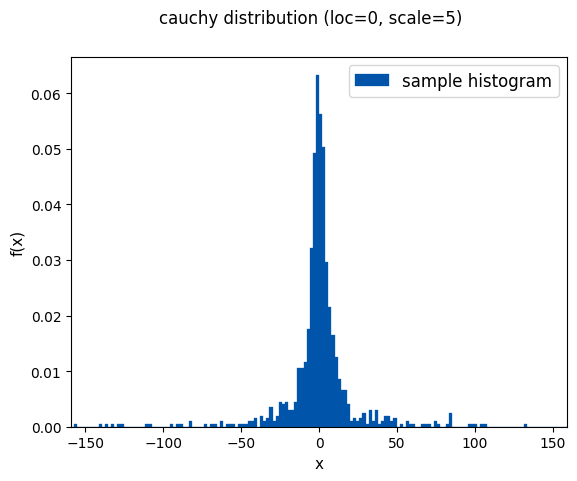

  LimitInf      = -4491.3851
  LimitSup      = 4188.3675

  Sample mean   = -151.5088
  Sample stddev = 4339.8763

  Negative tail probability mass:       0.2%
  Region within 1 stdDev from the mean: 99.8%
  Positive Tail  probability mass:      0.0%

  Contribute of negative tail to kurtosis:   982743.1407
  Contribute of non-tail region to kurtosis: 0.0107
  Contribute of positive tail to kurtosis:   0.0000

  Contribute of tails to kurtosis:   99.999999%
  Contribute of no-tail to kurtosis: 0.000001%
  Sample kurtosis: 982.74315


In [26]:
N     = 1000
loc   = 0
scale_arr = [1, 2, 5]

rng   = RandomState(seed=42)

for n, scale in enumerate(scale_arr):

    print( '-----------------------------------')
    print(f'Cauchy distribution with loc={loc} scale={scale}:')

    nx = np.linspace(
            cauchy.ppf(0.01, loc=loc, scale=scale), 
            cauchy.ppf(0.99, loc=loc, scale=scale),
            N)

    X = cauchy.rvs(loc=loc, scale=scale, size=N, random_state=rng)

    # plot the sample histogram
    
    fig, ax = plt.subplots(1, 1)
    ax.set_xlim([nx[0], nx[-1]])
    sns.histplot(ax=ax, data=X, stat='density', discrete=False, kde=False,
                facecolor='#0055AA', edgecolor='#0055AA', label='sample histogram')
    ax.set_ylabel('f(x)', fontsize=11)
    ax.set_xlabel('x', fontsize=11)
    fig.suptitle(f'cauchy distribution (loc={loc}, scale={scale})')
    plt.legend(loc='upper right', fontsize= 12)
    plt.show()

    X_mean    = X.mean()
    X_stddev  = X.std()
    limit_inf = X_mean - X_stddev
    limit_sup = X_mean + X_stddev

    print(f'  LimitInf      = {limit_inf:.4f}')
    print(f'  LimitSup      = {limit_sup:.4f}\n')
    print(f'  Sample mean   = {X_mean:.4f}')
    print(f'  Sample stddev = {X_stddev:.4f}\n')

    tail_neg  = (X <  limit_inf).sum()
    tail_pos  = (X >  limit_sup).sum()
    rest      = len(X)-tail_neg-tail_pos

    print(f'  Negative tail probability mass:       {(tail_neg*100)/N}%')
    print(f'  Region within 1 stdDev from the mean: {(rest*100)/N}%')
    print(f'  Positive Tail  probability mass:      {(tail_pos*100)/N}%\n')

    #.................................................

    Z                = (X - X_mean) / X_stddev

    X_kurt_tail_neg  = (Z[Z < -1]**4).sum()
    X_kurt_tail_pos  = (Z[Z > 1]**4).sum()
    X_kurt_not_tails = (Z[abs(Z) <= 1]**4).sum()
    X_kurt_total     = X_kurt_tail_neg + X_kurt_not_tails + X_kurt_tail_pos

    print(f'  Contribute of negative tail to kurtosis:   {X_kurt_tail_neg:.4f}')
    print(f'  Contribute of non-tail region to kurtosis: {X_kurt_not_tails:.4f}') 
    print(f'  Contribute of positive tail to kurtosis:   {X_kurt_tail_pos:.4f}\n') 

    tails_percent   = ((X_kurt_tail_neg+X_kurt_tail_pos)*100)/X_kurt_total
    notails_percent = 100 - tails_percent
    
    print(f'  Contribute of tails to kurtosis:   {tails_percent:.6f}%')
    print(f'  Contribute of no-tail to kurtosis: {notails_percent:.6f}%')

    print(f'  Sample kurtosis: {X_kurt_total/len(X):.5f}')
